In [1]:
from IPython.display import display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [3]:


# 1. Load Data
df = pd.read_csv('credit_card_fraud.csv').copy()
target_col = 'Class' 

In [4]:
 

# 2. EDA Flow
print(f'Shape: {df.shape}')
print('\nFirst 5 rows:')
display(df.head())


Shape: (284807, 31)

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:

print('\nData Types:')
display(df.dtypes.rename('dtype').to_frame())


Data Types:


,dtype
Time,float64
V1,float64
V2,float64
V3,float64
V4,float64
V5,float64
V6,float64
V7,float64
V8,float64
V9,float64


In [6]:


print('\nSummary Statistics:')
display(df.describe(include='all').T)


Summary Statistics:


,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [7]:


print(f'\nDuplicate rows: {df.duplicated().sum()}')
print('\nMissing Values:')
print(df.isna().sum())


Duplicate rows: 1081

Missing Values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


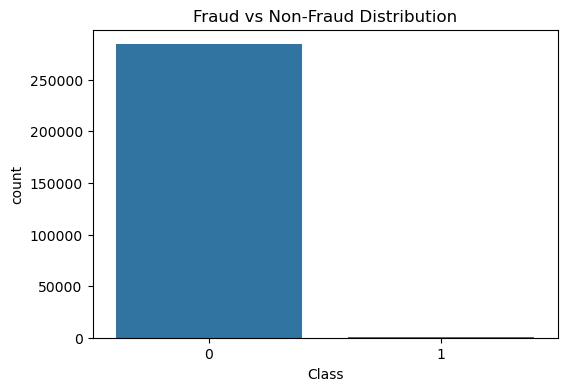

In [8]:


# Target Distribution Plot
plt.figure(figsize=(6,4))
sns.countplot(x=target_col, data=df)
plt.title("Fraud vs Non-Fraud Distribution")
plt.show()

In [9]:


# 3. Preprocessing
# Handling missing values (matching the flow in ml.ipynb)
for col in df.columns:
    if col != target_col:
        # Fill NaN with median for numerical features
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].fillna(df[col].median())


In [10]:


X = df.drop(target_col, axis=1)
y = df[target_col]


In [11]:

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [12]:

# PCA (Dimensionality Reduction to explain 95% variance)
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)


In [13]:

print(f"Original shape: {X.shape}")
print(f"PCA shape: {X_pca.shape}")


Original shape: (284807, 30)
PCA shape: (284807, 27)


In [14]:

# Train-Test Split (with stratification for imbalanced data)
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)

In [15]:


# 4. Model Comparison and GridSearchCV
# Following the structure in ml.ipynb
models = [
    ('Logistic', GridSearchCV(LogisticRegression(), {'C': [0.1, 1, 10]}, cv=5)),
    ('KNN', GridSearchCV(KNeighborsClassifier(), {'n_neighbors': [3, 5, 7]}, cv=5)),
    ('RandomForest', GridSearchCV(RandomForestClassifier(), {'n_estimators': [50, 100]}, cv=3))
]


In [ ]:

results = []

for name, grid in models:
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    results.append({
        'Model': name,
        'Best Params': grid.best_params_,
        'CV Best Score': round(grid.best_score_, 4),
        'Test Accuracy': round(accuracy_score(y_test, y_pred), 4)
    })

# Final Results
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='Test Accuracy', ascending=False).reset_index(drop=True)

print("\nModel Comparison")
display(results_df)

print("\nBest model on test data:", results_df.loc[0, 'Model'])

e:\anaconda\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "e:\anaconda\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "e:\anaconda\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "e:\anaconda\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "e:\anaconda\Lib\subprocess.py", line